Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded',
       'Turnover (₹ Cr)'],
      dtype='object')
Accuracy Score: 0.9615384615384616

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      0.92      0.96        13
    Positive       0.93      1.00      0.96        13

    accuracy                           0.96        26
   macro avg       0.96      0.96      0.96        26
weighted avg       0.96      0.96      0.96        26


Confusion Matrix:
 [[12  1]
 [ 0 13]]


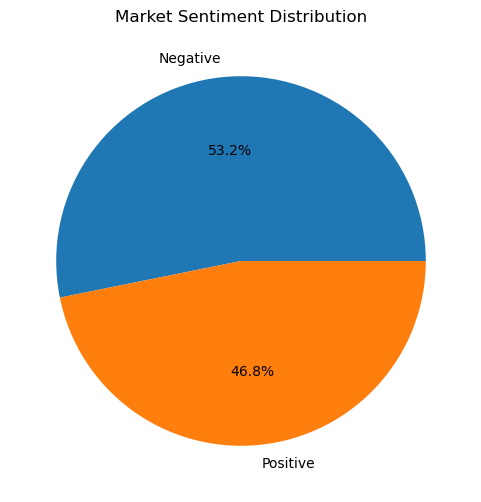

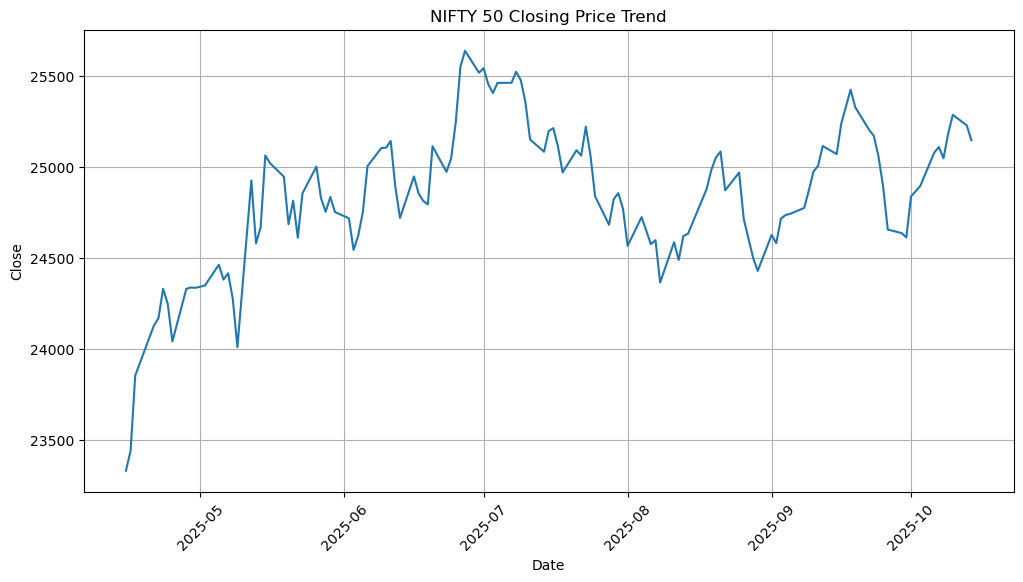

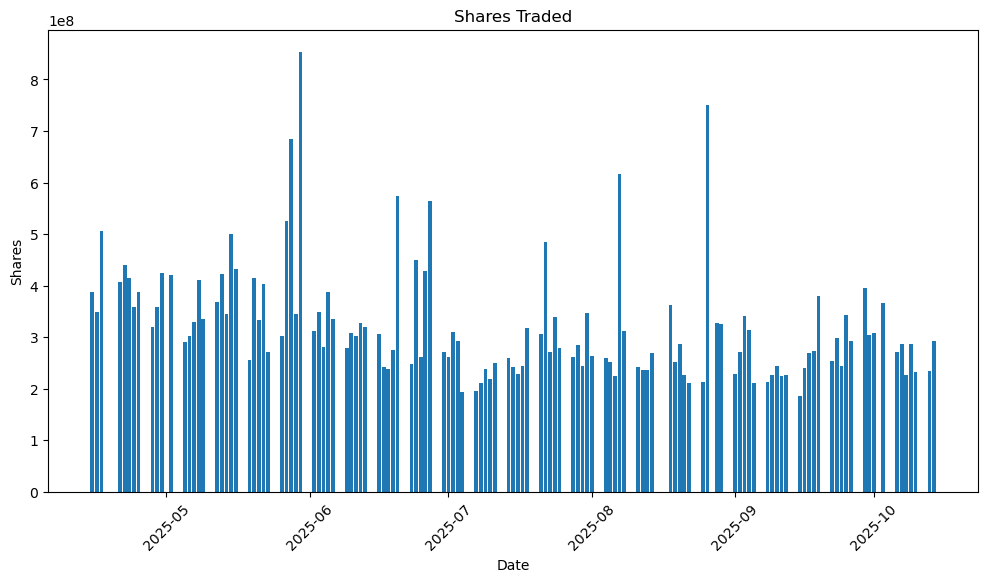

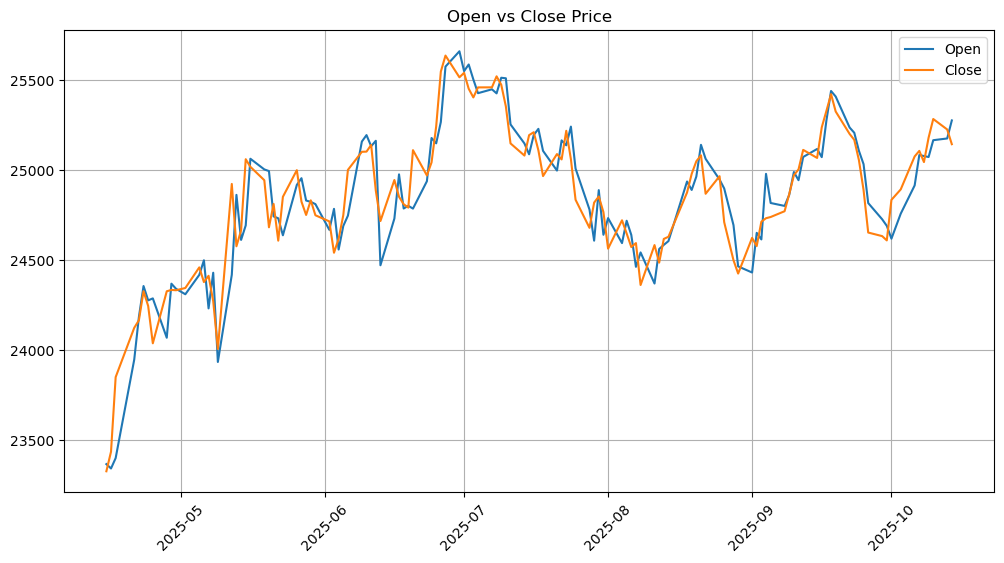

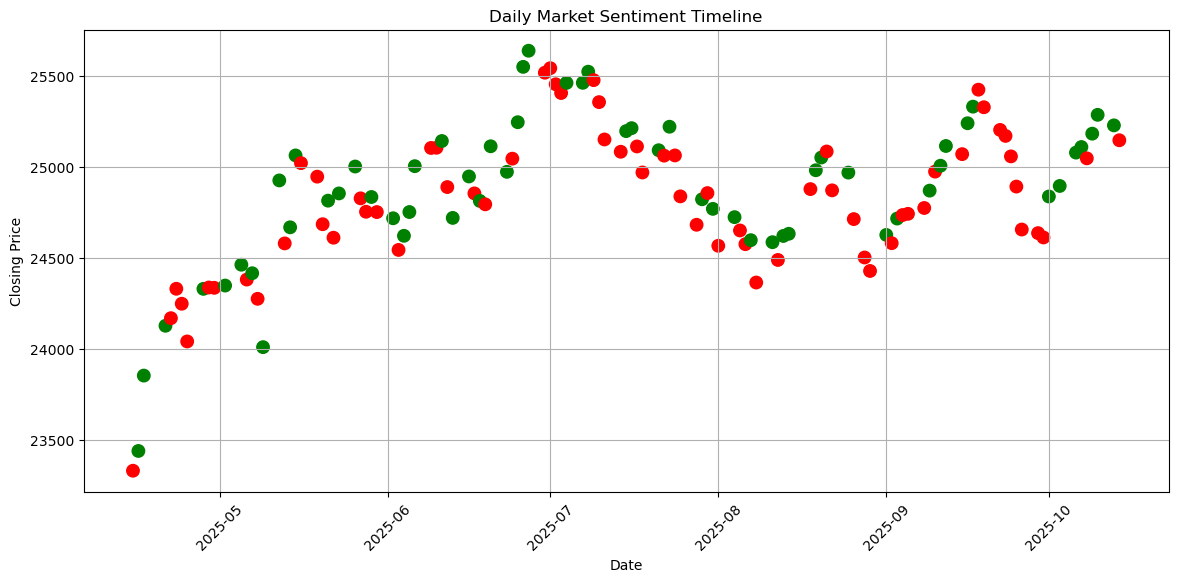

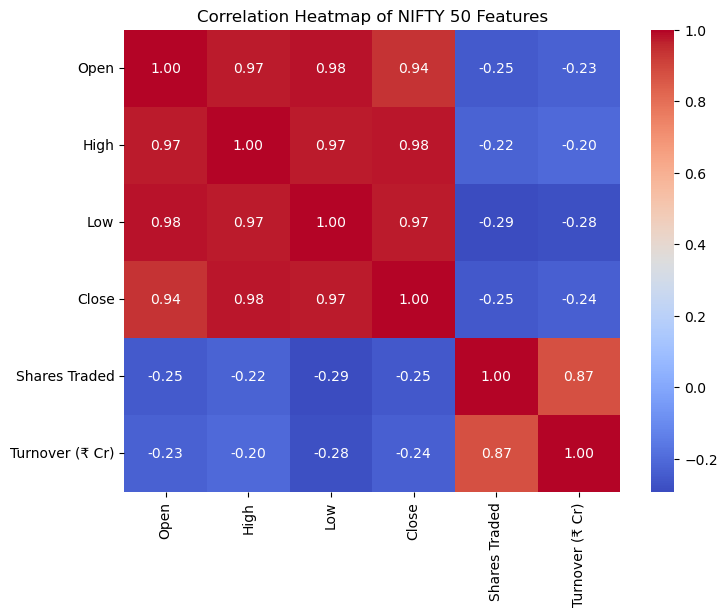

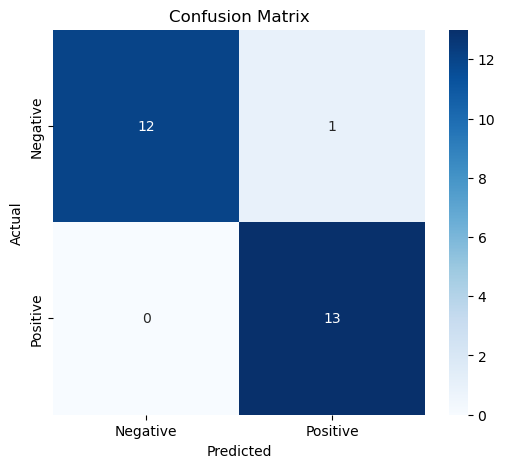

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv(r"C:\Users\Khushi Mathur\Downloads\NIFTY 50-15-04-2025-to-15-10-2025 python dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns)

# Remove commas and convert numeric columns
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']

for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Create Sentiment Labels
df['Sentiment'] = np.where(df['Close'] > df['Open'], 'Positive',
                    np.where(df['Close'] < df['Open'], 'Negative', 'Negative'))

# Features
X = df[['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']]
y = df['Sentiment']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))

# ------------------------------
# DATA VISUALIZATION
# ------------------------------

# 1 Sentiment Pie Chart
plt.figure(figsize=(6,6))
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Market Sentiment Distribution")
plt.ylabel("")
plt.show()

# 2 Closing Price Trend
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("NIFTY 50 Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 3 Shares Traded
plt.figure(figsize=(12,6))
plt.bar(df['Date'], df['Shares Traded'])
plt.title("Shares Traded")
plt.xlabel("Date")
plt.ylabel("Shares")
plt.xticks(rotation=45)
plt.show()

# 4 Open vs Close
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')
plt.title("Open vs Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(14,6))

colors = df['Sentiment'].map({'Positive':'green','Negative':'red'})

plt.scatter(df['Date'], df['Close'], c=colors, s=80)

plt.title("Daily Market Sentiment Timeline")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

import seaborn as sns

# Correlation matrix
corr = df[['Open','High','Low','Close','Shares Traded','Turnover (₹ Cr)']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Correlation Heatmap of NIFTY 50 Features")
plt.show()

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
